In [52]:
import os
from dotenv import load_dotenv
import xarray as xr

import geopandas as gpd
import matplotlib.pyplot as plt

import analysis_utils
import isku_utils

import importlib

importlib.reload(analysis_utils)
importlib.reload(isku_utils)

<module 'isku_utils' from '/home/emily_zuetell/projects/poreallas/analysis/isku_utils.py'>

In [53]:
load_dotenv()
DATA_DIR = os.environ["DATA_DIR"]
# EFFECTS_URI = os.environ["POREALLAS_EFFECTS_URI"]
EFFECTS_URI_EZ = (
    "/home/emily_zuetell/projects/poreallas/data/2608_effect_gamma_sampled.zarr"
)
EFFECTS_URI_BM = "gs://poreallas-public-20260605/v20260827/parsed/effects.zarr"
IMPACT_REGION_POLYGONS = os.environ["POREALLAS_REGIONS_POLYGONS_URI"]
SOCIOECONOMICS_URI = os.environ["POREALLAS_SOCIOECONOMICS_URI"]

In [54]:
# Projection Effects
effect_ez = xr.open_datatree(os.path.join(DATA_DIR, EFFECTS_URI_EZ), consolidated=False)
effect_bm = xr.open_datatree(
    EFFECTS_URI_BM,
    engine="zarr",
    chunks={},
    backend_kwargs={"storage_options": {"token": "anon"}},
)

baseline_period = analysis_utils.get_baseline_period(effect_ez, years=30)
# Impact Regions
_polygons = (
    gpd.read_parquet(os.path.join(DATA_DIR, IMPACT_REGION_POLYGONS))
    .rename(columns={"hierid": "region"})
    .set_index("region")
    .set_crs(epsg=4326)  # Assuming the data is WGS-82.
)

# Socioeconomics
socioeconomics = xr.open_zarr(os.path.join(DATA_DIR, SOCIOECONOMICS_URI))
socioeconomics = socioeconomics.sel(year=2026)[
    ["pop0to4", "pop5to64", "pop65plus", "pop", "gdppc", "iso3"]
]

In [56]:
forecast_parsed_ez = "/home/emily_zuetell/projects/poreallas/data/parsed/08_ecmwf_parsed.zarr"
forecast_parsed_bm = "gs://poreallas-public-20260605/v20260825/parsed/forecast.zarr"

In [57]:
forecast_ez = xr.open_datatree(forecast_parsed_ez, consolidated=False)
forecast_bm = xr.open_datatree(
    forecast_parsed_bm,
    engine="zarr",
    chunks={},
    backend_kwargs={"storage_options": {"token": "anon"}},
)

In [59]:
forecast_bm

<xarray.DataTree>
Group: /
    Dimensions:                  (number: 51, latitude: 180, longitude: 360,
                                  time: 9879)
    Coordinates:
      * number                   (number) int64 408B 0 1 2 3 4 5 ... 46 47 48 49 50
      * latitude                 (latitude) float64 1kB 89.5 88.5 ... -88.5 -89.5
      * longitude                (longitude) float64 3kB 0.5 1.5 2.5 ... 358.5 359.5
      * time                     (time) object 79kB 1981-08-02 00:00:00 ... 2027-...
        forecast_period          (time) timedelta64[ns] 79kB dask.array<chunksize=(9879,), meta=np.ndarray>
        forecast_reference_time  (time) datetime64[ns] 79kB dask.array<chunksize=(9879,), meta=np.ndarray>
    Data variables:
        tas                      (number, latitude, longitude, time) float32 131GB dask.array<chunksize=(51, 30, 2, 9879), meta=np.ndarray>
    Attributes:
        poreallas_created_at:   2026-08-26T03:14:40.771900+00:00
        poreallas_uid:          ee09ab32-b95b-4cfb-8d11-cbfdd954b66b
        poreallas_description:  Parsed ECMWF S51 ensemble fields

In [73]:
diff = forecast_ez.isel(latitude = 100, longitude = 100)-forecast_bm.isel(latitude = 100, longitude = 100)

In [78]:
diff['tas'].max().values

array(0., dtype=float32)

In [79]:
diff['tas'].min().values

array(0., dtype=float32)

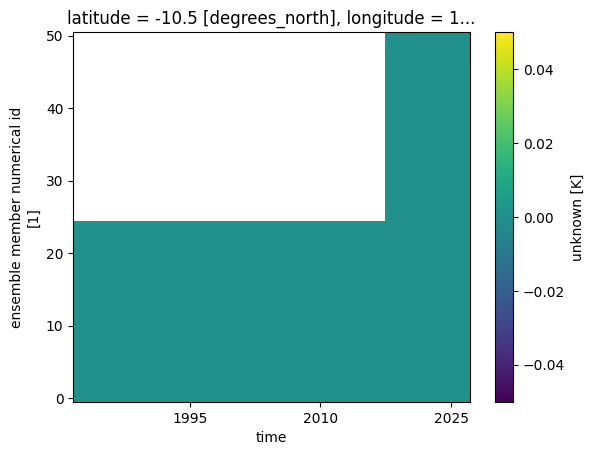

In [76]:
diff['tas'].plot()

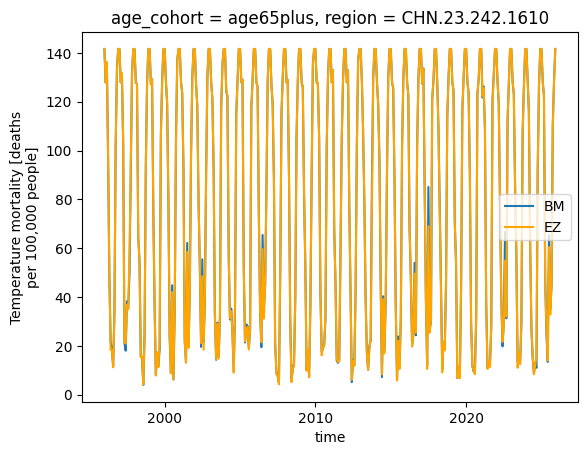

In [55]:
region_i = 7000
effect_bm["/baseline"]["effect"].isel(region=region_i).sel(
    age_cohort="age65plus"
).median(dim="sample").plot(label="BM")

effect_ez["/baseline"]["effect"].isel(region=region_i).sel(
    age_cohort="age65plus"
).median(dim="sample").plot(label="EZ", color="orange")
plt.legend()

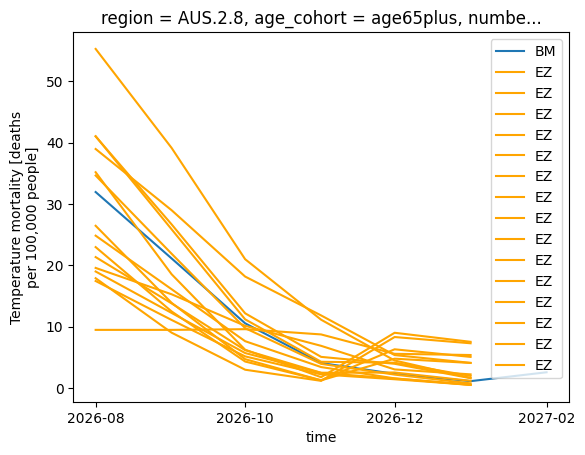

In [ ]:
region_i = 1000

for i in range(15):
    effect_bm["/forecast"]["effect"].isel(region=region_i, number=10).sel(
    age_cohort="age65plus"
    ).sel(sample=i).plot(label="BM", color="blue")
    effect_ez["/forecast"]["effect"].isel(region=region_i, number=10).sel(
        age_cohort="age65plus"
    ).sel(sample=i).plot(label="EZ", color="orange")
plt.legend()

In [50]:
impact_ez = analysis_utils.compute_impact(
    effect_ez,
    socioeconomics,
    ensemble=True,
    baseline_period=baseline_period,
    hotonly="net",
    rate=False,
    age_weight=True,
    chunks={"number": -1, "region": "auto"},
)
impact_bm = analysis_utils.compute_impact(
    effect_bm,
    socioeconomics,
    ensemble=True,
    baseline_period=baseline_period,
    hotonly="net",
    rate=False,
    age_weight=True,
    chunks={"number": -1, "region": "auto"},
)
q_diff = impact_ez - impact_bm.sel(month=[8, 9, 10, 11, 12, 1])
_polygons_impact = analysis_utils.xarray_to_gpd(
    q_diff.sum(dim="month").mean(dim="number"), _polygons
)

/home/emily_zuetell/projects/poreallas/.venv/lib/python3.14/site-packages/dask/array/core.py:5200: PerformanceWarning: Increasing number of chunks by factor of 16
  result = blockwise(


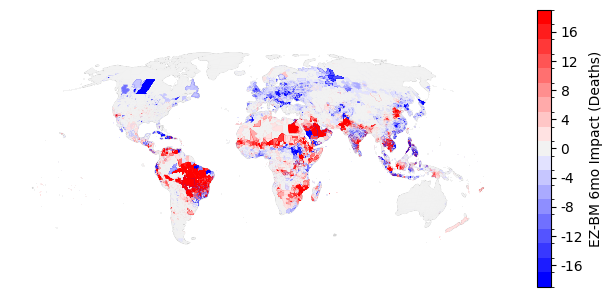

In [51]:
fig = analysis_utils.plot_single(
    _polygons_impact,
    col="age_weighted_impact",
    n_colors=11,
    cm="bwr",
    sup_title="",
    cbar_label="EZ-BM 6mo Impact (Deaths)",
)

# Number of Quantiles

In [23]:
EFFECTS_URI_100 = "gs://poreallas-public-20260605/v20260825/parsed/effects-q100.zarr"
EFFECTS_URI_20 = "gs://poreallas-public-20260605/v20260825/parsed/effects-q20.zarr"

In [24]:
effect_100 = xr.open_datatree(
    EFFECTS_URI_100,
    engine="zarr",
    chunks={},
    backend_kwargs={"storage_options": {"token": "anon"}},
)
effect_20 = xr.open_datatree(
    EFFECTS_URI_20,
    engine="zarr",
    chunks={},
    backend_kwargs={"storage_options": {"token": "anon"}},
)

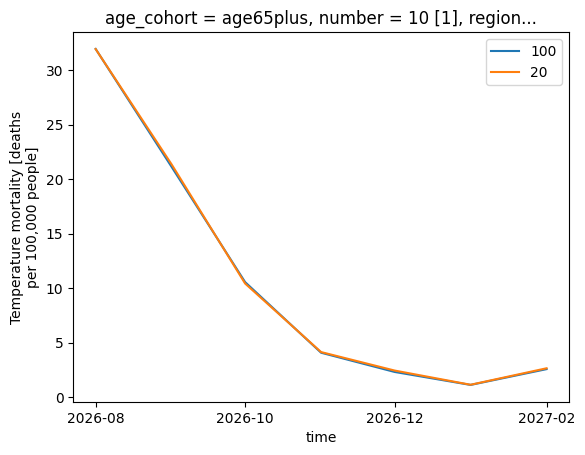

In [25]:
region_i = 1000
effect_100["/forecast"]["effect"].isel(region=region_i, number=10).sel(
    age_cohort="age65plus"
).plot(label="100")
effect_20["/forecast"]["effect"].isel(region=region_i, number=10).sel(
    age_cohort="age65plus"
).plot(label="20")
plt.legend()

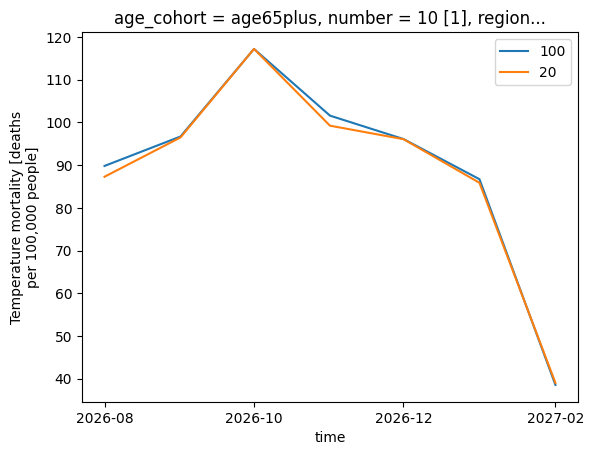

In [26]:
region_i = 10000
effect_100["/forecast"]["effect"].isel(region=region_i, number=10).sel(
    age_cohort="age65plus"
).plot(label="100")
effect_20["/forecast"]["effect"].isel(region=region_i, number=10).sel(
    age_cohort="age65plus"
).plot(label="20")
plt.legend()

In [ ]:
impact_100 = analysis_utils.compute_impact(
    effect_100,
    socioeconomics,
    ensemble=True,
    baseline_period=baseline_period,
    hotonly="net",
    rate=False,
    age_weight=True,
    chunks={"number": -1, "region": "auto"},
)
impact_20 = analysis_utils.compute_impact(
    effect_20,
    socioeconomics,
    ensemble=True,
    baseline_period=baseline_period,
    hotonly="net",
    rate=False,
    age_weight=True,
    chunks={"number": -1, "region": "auto"},
)
q_diff = impact_100 - impact_20
_polygons_impact = analysis_utils.xarray_to_gpd(
    q_diff.sum(dim="month").mean(dim="number"), _polygons
)

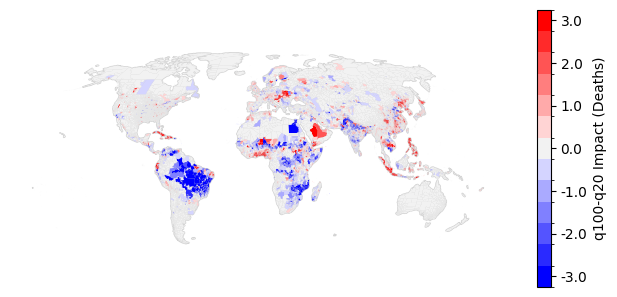

In [33]:
fig = analysis_utils.plot_single(
    _polygons_impact,
    col="age_weighted_impact",
    n_colors=11,
    cm="bwr",
    sup_title="",
    cbar_label="q100-q20 Impact (Deaths)",
)